In [123]:
import pandas as pd
import pickle
import numpy as np
import os

output_base = 'output/data' 
df_raw = pickle.load(open(f'{output_base}/df_raw.pkl', "rb"))
df_ML = pickle.load(open(f'{output_base}/df_ML.pkl', "rb"))
df_ML_unscaled = pickle.load(open(f'{output_base}/df_ML_unscaled.pkl', "rb"))
feature_names = pickle.load(open(f'{output_base}/feature_names.pkl', "rb"))

figure_path = 'output/figures'
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

In [88]:
feature_names

['total_press_duration',
 'max_force',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'sex']

In [61]:
# distribution of sex
df_raw2 = df_raw.drop_duplicates(subset=['id'])
rat_gender_count = df_raw2.sex.value_counts(dropna=False).to_dict()

print(f"males: {rat_gender_count.get(0, 0)}")
print(f"females: {rat_gender_count.get(1, 0)}")
print(f"total: {len(df_raw2)}")

males: 33
females: 8
total: 41


In [65]:
# number of sessions
session_num = df_raw.groupby('category').count()['id'].to_dict()
print(f"number of sessions by group: {session_num}")

# session duration
df_raw['raw_data_len'] = df_raw['raw_data'].apply(lambda x: len(x) / 100)
df_raw.groupby('category')['raw_data_len'].mean()


number of sessions by group: {'EXT': 60, 'FR1': 82}


category
EXT    3709.736667
FR1     877.809268
Name: raw_data_len, dtype: float64

In [79]:
df_ML_unscaled.groupby('category')['total_press_duration'].agg(
    ['mean', 'std','min','max']
)

,mean,std,min,max
category,,,,
EXT,75.636489,58.286986,10,497
FR1,60.307799,51.035342,10,498


# Descriptive table for features

In [89]:
import pandas as pd
from scipy.stats import ttest_ind

# Features to include (matching your table)
features = [
    'total_press_duration',
    'max_force',
    'pk_num',
    'pk_widths_max',
    'pk_widths_mean',
    'pk_widths_min',
    'pk_sharp_max',
    'pk_sharp_mean',
    'pk_sharp_min',
    'skewness',
    'kurtosis',
    'avg_first_5',
    'avg_last_5',
    'force_variation_rate'
]

# Optional: rename features to match paper formatting
feature_name_map = {
    'total_press_duration': 'Press Duration',
    'max_force': 'Max Force',
    'pk_num': 'Peak Number',
    'pk_widths_max': 'Max Peak Width',
    'pk_widths_mean': 'Mean Peak Width',
    'pk_widths_min': 'Min Peak Width',
    'pk_sharp_max': 'Max Peak Sharpness',
    'pk_sharp_mean': 'Mean Peak Sharpness',
    'pk_sharp_min': 'Min Peak Sharpness',
    'skewness': 'Skewness',
    'kurtosis': 'Kurtosis',
    'avg_first_5': 'Average First 5 Samples',
    'avg_last_5': 'Average Last 5 Samples',
    'force_variation_rate': 'Force Variation Rate'
}



results = []

for feat in features:
    fr1 = df_ML_unscaled[df_ML_unscaled['category'] == 'FR1'][feat].dropna()
    ext = df_ML_unscaled[df_ML_unscaled['category'] == 'EXT'][feat].dropna()
    
    # Descriptive stats
    fr1_mean, fr1_sd = fr1.mean(), fr1.std()
    ext_mean, ext_sd = ext.mean(), ext.std()
    
    # Welch’s t-test
    t_stat, p_val = ttest_ind(fr1, ext, equal_var=False)
    
    results.append({
        'Feature': feature_name_map.get(feat, feat),
        'FR1 (Mean ± SD)': f"{fr1_mean:.2f} ± {fr1_sd:.2f}",
        'EXT (Mean ± SD)': f"{ext_mean:.2f} ± {ext_sd:.2f}",
        'P-value': "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    })

# Create final table
df_table = pd.DataFrame(results)

# Display in notebook
display(df_table)

# Optional: export to LaTeX
latex_table = df_table.to_latex(index=False, escape=False)
print(latex_table)

,Feature,FR1 (Mean ± SD),EXT (Mean ± SD),P-value
0,Press Duration,60.31 ± 51.04,75.64 ± 58.29,<0.001
1,Max Force,44.11 ± 42.98,43.08 ± 31.69,0.036
2,Peak Number,1.25 ± 0.94,1.48 ± 1.04,<0.001
3,Max Peak Width,21.70 ± 16.48,28.41 ± 22.05,<0.001
4,Mean Peak Width,19.13 ± 12.59,23.09 ± 15.39,<0.001
5,Min Peak Width,17.00 ± 12.37,18.69 ± 14.95,<0.001
6,Max Peak Sharpness,2.04 ± 3.45,1.86 ± 2.96,<0.001
7,Mean Peak Sharpness,1.90 ± 3.39,1.66 ± 2.85,<0.001
8,Min Peak Sharpness,1.78 ± 3.40,1.48 ± 2.84,<0.001
9,Skewness,-0.03 ± 0.67,-0.14 ± 0.71,<0.001


\begin{tabular}{llll}
\toprule
Feature & FR1 (Mean ± SD) & EXT (Mean ± SD) & P-value \\
\midrule
Press Duration & 60.31 ± 51.04 & 75.64 ± 58.29 & <0.001 \\
Max Force & 44.11 ± 42.98 & 43.08 ± 31.69 & 0.036 \\
Peak Number & 1.25 ± 0.94 & 1.48 ± 1.04 & <0.001 \\
Max Peak Width & 21.70 ± 16.48 & 28.41 ± 22.05 & <0.001 \\
Mean Peak Width & 19.13 ± 12.59 & 23.09 ± 15.39 & <0.001 \\
Min Peak Width & 17.00 ± 12.37 & 18.69 ± 14.95 & <0.001 \\
Max Peak Sharpness & 2.04 ± 3.45 & 1.86 ± 2.96 & <0.001 \\
Mean Peak Sharpness & 1.90 ± 3.39 & 1.66 ± 2.85 & <0.001 \\
Min Peak Sharpness & 1.78 ± 3.40 & 1.48 ± 2.84 & <0.001 \\
Skewness & -0.03 ± 0.67 & -0.14 ± 0.71 & <0.001 \\
Kurtosis & -0.48 ± 1.09 & -0.24 ± 1.22 & <0.001 \\
Average First 5 Samples & 14.49 ± 5.59 & 15.18 ± 5.69 & <0.001 \\
Average Last 5 Samples & 13.35 ± 15.97 & 12.94 ± 12.41 & 0.027 \\
Force Variation Rate & 7.82 ± 11.52 & 7.09 ± 8.24 & <0.001 \\
\bottomrule
\end{tabular}



# Headmap

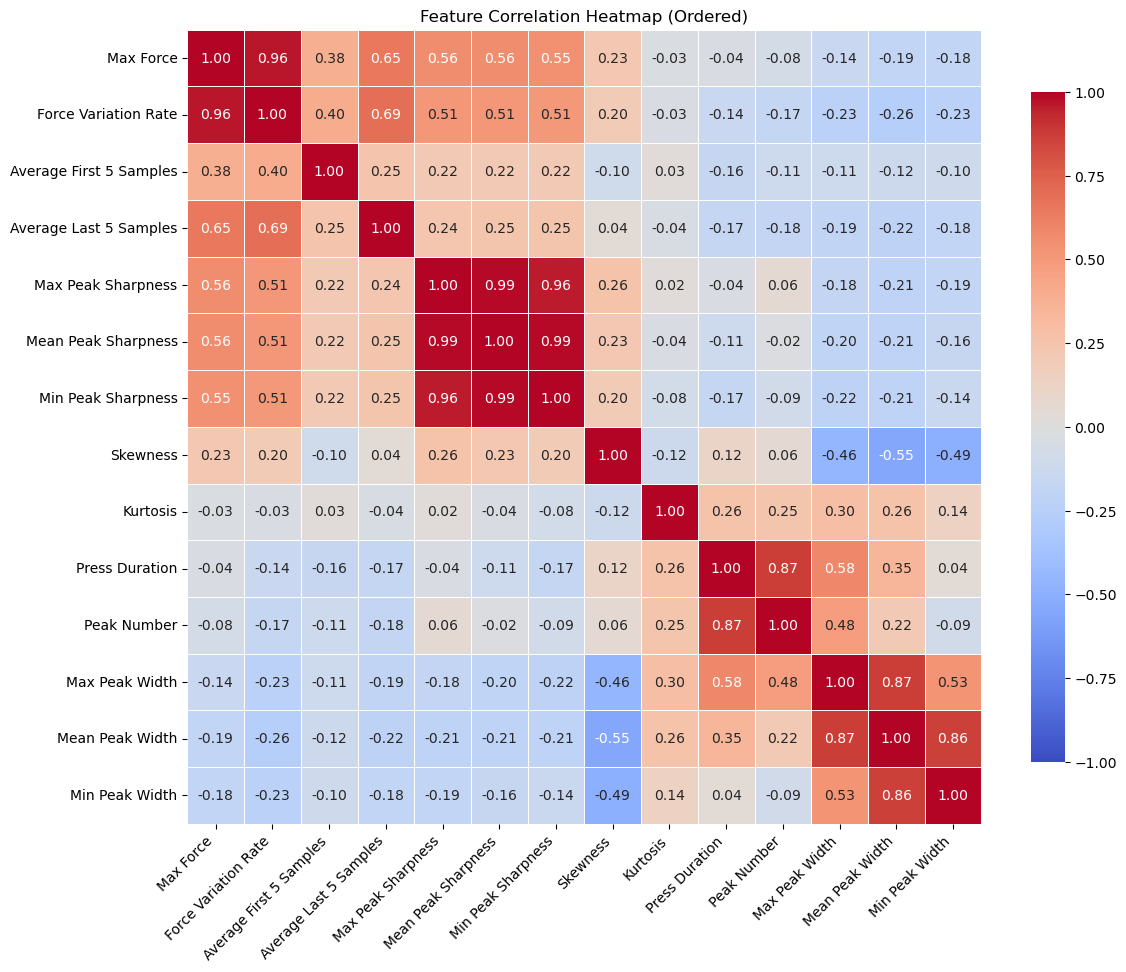

<Figure size 640x480 with 0 Axes>

In [140]:
ordered_features = [
    'max_force',
    'force_variation_rate',
    'avg_first_5',
    'avg_last_5',
    'pk_sharp_max',
    'pk_sharp_mean',
    'pk_sharp_min',
    'skewness',
    'kurtosis',
    'total_press_duration',
    'pk_num',
    'pk_widths_max',
    'pk_widths_mean',
    'pk_widths_min'
]

# Keep only features that exist in your mapping
base_features = list(feature_name_map.keys())

# Add any missing ones at the end
final_order = ordered_features + [f for f in base_features if f not in ordered_features]

# Select + reorder + rename
df_features = df_ML_unscaled[final_order].copy()
df_features.rename(columns=feature_name_map, inplace=True)

# Correlation
corr_matrix = df_features.corr()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',   
    vmin=-1, vmax=1,   
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap (Ordered)")
plt.tight_layout()
plt.show()
plt.savefig(f"{figure_path}/correlation.png", dpi=300, bbox_inches='tight')

# Model Evaluation

In [133]:
import os, pickle
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score

df_ML_train = pickle.load(open(os.path.join(output_base, "df_ML_train.pkl"), "rb"))
df_ML_test = pickle.load(open(os.path.join(output_base, "df_ML_test.pkl"), "rb"))
feature_names = pickle.load(open(os.path.join(output_base, "feature_names.pkl"), "rb"))


x_train = df_ML_train.loc[:, feature_names]
y_train = df_ML_train.loc[:, 'label'].values
x_test = df_ML_test.loc[:, feature_names]
y_test = df_ML_test.loc[:, 'label'].values

print(feature_names)
print(f"{len(x_train)} training samples, {len(x_test)} testing samples")


['total_press_duration', 'max_force', 'pk_num', 'pk_widths_max', 'pk_widths_mean', 'pk_widths_min', 'pk_sharp_max', 'pk_sharp_mean', 'pk_sharp_min', 'skewness', 'kurtosis', 'force_variation_rate', 'avg_first_5', 'avg_last_5', 'sex']
19749 training samples, 3404 testing samples


In [134]:

from sklearn.metrics import f1_score, recall_score, precision_score

def calc_metrics(y_true, y_prob):
    thresholds = np.unique(y_prob)
    best_threshold = 0.5
    best_f1 = -1.0

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(t)

    y_pred_t = (y_prob >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    recall = recall_score(y_true, y_pred_t, zero_division=0)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    return {
        "threshold": round(best_threshold, 3),
        "f1_score": round(f1, 3),
        "recall": round(recall, 3),
        "precision": round(precision, 3),
        "auc": round(auc, 3),
    }

## Logistic

In [135]:
from sklearn.linear_model import LogisticRegression
C = 0.01
lg = LogisticRegression(max_iter=10000, l1_ratio=1.0, C=C, solver='liblinear')
lg.fit(x_train, y_train)
y_pred = lg.predict_proba(x_test)[:, 1]
LG_metrics = calc_metrics(y_test, y_pred)
print(LG_metrics)

{'threshold': 0.109, 'f1_score': 0.562, 'recall': 1.0, 'precision': 0.391, 'auc': 0.574}


# GB

In [136]:
import xgboost as xgb

gb = xgb.XGBClassifier(
    max_depth=2,
    min_child_weight=8,
    subsample=1,
    colsample_bytree=1,
    reg_lambda=1,
    tree_method="hist",
    random_state=42
)


gb.fit(x_train, y_train)
y_pred = gb.predict_proba(x_test)[:, 1]
GB_metrics = calc_metrics(y_test, y_pred)
print(GB_metrics)


{'threshold': 0.278, 'f1_score': 0.583, 'recall': 0.841, 'precision': 0.446, 'auc': 0.655}


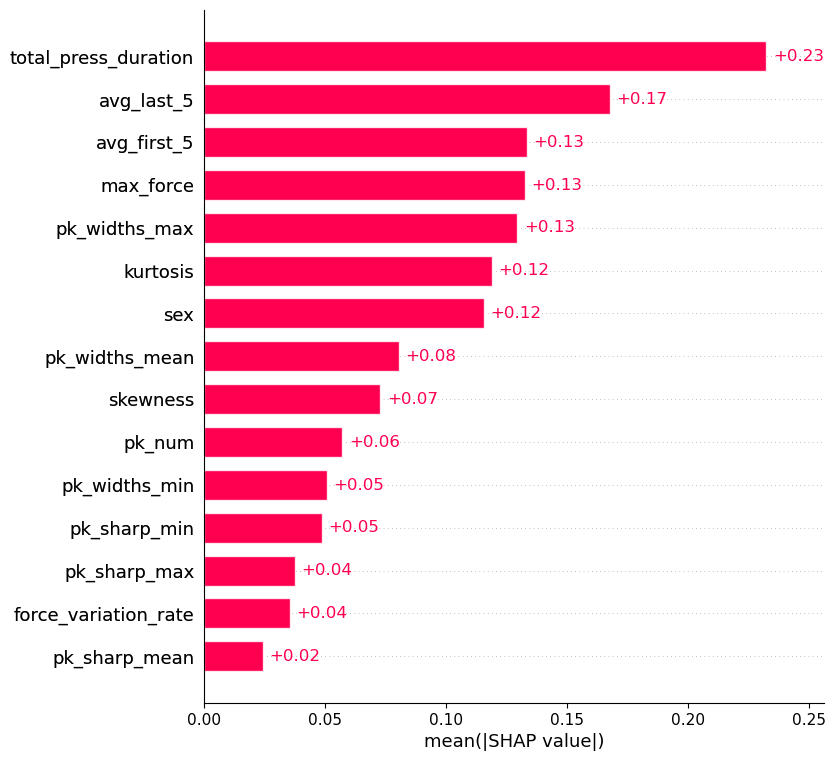

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import matplotlib.pyplot as plt

expl_gb = shap.Explainer(gb, x_train)
shap_values = expl_gb(x_test)

shap.plots.bar(shap_values, max_display=30)
plt.show()

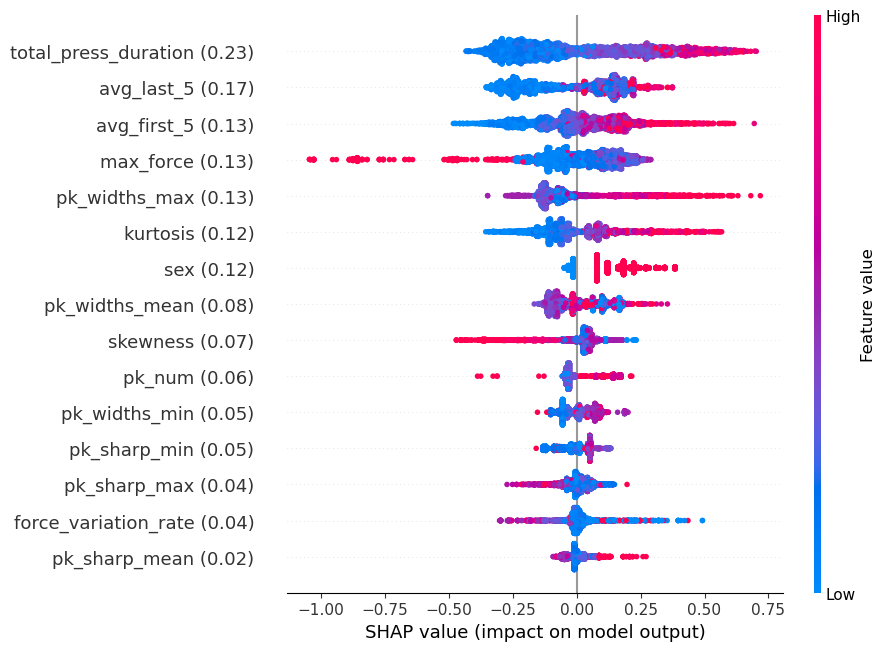

<Figure size 640x480 with 0 Axes>

In [158]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Compute SHAP values
shap_values = expl_gb(x_test)

# Mean absolute SHAP per feature
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Append mean SHAP to feature names
shap_values.feature_names = [
    f"{name} ({mean_shap[i]:.2f})"
    for i, name in enumerate(x_test.columns)
]

# Plot
shap.plots.beeswarm(shap_values, max_display=30)
plt.show()
plt.savefig(f"{figure_path}/shap_plot_GB.png", dpi=300, bbox_inches='tight')

# GRU

In [154]:
from modules.nn_models import GRUModel
from modules.nn_train import dataframe_to_tensors
import torch

gru = GRUModel(input_size=1, hidden_size=256, num_layers=4, feature_size=0)

# load output/gru_models/vgysgbiu/best_model.pt
gru.load_state_dict(torch.load(f"output/gru_models/vgysgbiu/best_model.pt"))


device = "cpu"
nn_test = df_ML_test[['label', 'data']]
nn_test_x, nn_test_y, nn_test_lengths = dataframe_to_tensors(nn_test, device=device)
gru.eval()
with torch.no_grad():
    y_pred_tensor = gru(nn_test_x, nn_test_lengths)
    y_pred = y_pred_tensor.squeeze().numpy()
    # sigmoid to convert logits to probabilities
    y_pred = 1 / (1 + np.exp(-y_pred)) 
    
gru_metrics = calc_metrics(y_test, y_pred[:,1])
print(gru_metrics)

{'threshold': 0.38, 'f1_score': 0.578, 'recall': 0.909, 'precision': 0.423, 'auc': 0.651}
